# Chapter 5 — Live Demos

Three demos to accompany the Chapter 5 slides.  
Based on the [companion notebook](https://github.com/DrEntropy/deep-learning-with-python-notebooks) for *Deep Learning with Python, 3rd Edition*.

In [1]:
import os
os.environ["KERAS_BACKEND"] = "jax"

import numpy as np
import matplotlib.pyplot as plt
import keras
from keras import layers

---
## Demo 1 — Noise channels on MNIST

Adding 784 random-noise channels doubles the input size.  
The model *should* ignore them — but it can't.

In [2]:
from keras.datasets import mnist

(train_images, train_labels), _ = mnist.load_data()
train_images = train_images.reshape((60000, 28 * 28)).astype("float32") / 255

train_images_with_noise = np.concatenate(
    [train_images, np.random.random((len(train_images), 784))], axis=1
)
train_images_with_zeros = np.concatenate(
    [train_images, np.zeros((len(train_images), 784))], axis=1
)

11490434/11490434 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


In [3]:
def get_mnist_model():
    model = keras.Sequential([
        layers.Dense(512, activation="relu"),
        layers.Dense(10, activation="softmax"),
    ])
    model.compile(optimizer="adam",
                  loss="sparse_categorical_crossentropy",
                  metrics=["accuracy"])
    return model

model = get_mnist_model()
history_noise = model.fit(
    train_images_with_noise, train_labels,
    epochs=10, batch_size=128, validation_split=0.2)

model = get_mnist_model()
history_zeros = model.fit(
    train_images_with_zeros, train_labels,
    epochs=10, batch_size=128, validation_split=0.2)

Epoch 1/10
375/375 ━━━━━━━━━━━━━━━━━━━━ 4s 7ms/step - accuracy: 0.7812 - loss: 0.7117 - val_accuracy: 0.9174 - val_loss: 0.2807
Epoch 2/10
375/375 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.9264 - loss: 0.2476 - val_accuracy: 0.9430 - val_loss: 0.2012
Epoch 3/10
375/375 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.9522 - loss: 0.1646 - val_accuracy: 0.9502 - val_loss: 0.1700
Epoch 4/10
375/375 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.9667 - loss: 0.1125 - val_accuracy: 0.9597 - val_loss: 0.1479
Epoch 5/10
375/375 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.9768 - loss: 0.0836 - val_accuracy: 0.9598 - val_loss: 0.1323
Epoch 6/10
375/375 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.9859 - loss: 0.0537 - val_accuracy: 0.9592 - val_loss: 0.1357
Epoch 7/10
375/375 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.9906 - loss: 0.0385 - val_accuracy: 0.9597 - val_loss: 0.1344
Epoch 8/10
375/375 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.9930 - loss: 0.0285 - val_accuracy: 0.

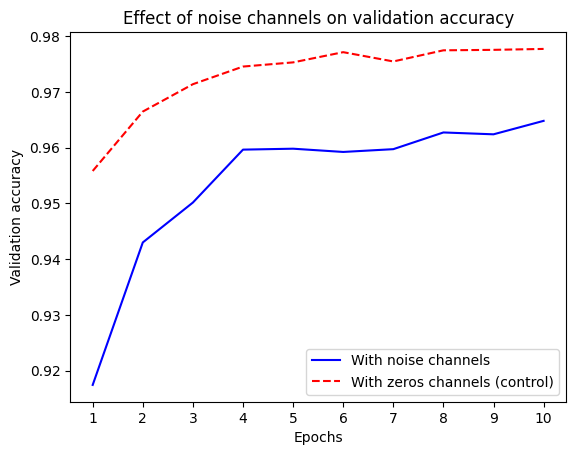

In [4]:
epochs = range(1, 11)
plt.plot(epochs, history_noise.history["val_accuracy"], "b-",
         label="With noise channels")
plt.plot(epochs, history_zeros.history["val_accuracy"], "r--",
         label="With zeros channels (control)")
plt.title("Effect of noise channels on validation accuracy")
plt.xlabel("Epochs")
plt.ylabel("Validation accuracy")
plt.xticks(epochs)
plt.legend()
plt.show()

---
## Demo 2 — Model size and overfitting (IMDB)

Train a baseline model and a much larger model on IMDB sentiment classification.  
The bigger model overfits dramatically.

In [5]:
from keras.datasets import imdb

(train_data, train_labels), _ = imdb.load_data(num_words=10000)

def vectorize_sequences(sequences, dimension=10000):
    results = np.zeros((len(sequences), dimension))
    for i, sequence in enumerate(sequences):
        results[i, sequence] = 1.0
    return results

train_data = vectorize_sequences(train_data)

17464789/17464789 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


In [6]:
# Baseline: 16-unit layers
model = keras.Sequential([
    layers.Dense(16, activation="relu"),
    layers.Dense(16, activation="relu"),
    layers.Dense(1, activation="sigmoid"),
])
model.compile(optimizer="rmsprop",
              loss="binary_crossentropy",
              metrics=["accuracy"])
history_original = model.fit(
    train_data, train_labels,
    epochs=20, batch_size=512, validation_split=0.4)

Epoch 1/20
30/30 ━━━━━━━━━━━━━━━━━━━━ 3s 82ms/step - accuracy: 0.6877 - loss: 0.6038 - val_accuracy: 0.8714 - val_loss: 0.3927
Epoch 2/20
30/30 ━━━━━━━━━━━━━━━━━━━━ 1s 12ms/step - accuracy: 0.8967 - loss: 0.3348 - val_accuracy: 0.8853 - val_loss: 0.3103
Epoch 3/20
30/30 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - accuracy: 0.9217 - loss: 0.2410 - val_accuracy: 0.8783 - val_loss: 0.3047
Epoch 4/20
30/30 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - accuracy: 0.9420 - loss: 0.1921 - val_accuracy: 0.8845 - val_loss: 0.2900
Epoch 5/20
30/30 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - accuracy: 0.9547 - loss: 0.1496 - val_accuracy: 0.8868 - val_loss: 0.2902
Epoch 6/20
30/30 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - accuracy: 0.9612 - loss: 0.1253 - val_accuracy: 0.8865 - val_loss: 0.2912
Epoch 7/20
30/30 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - accuracy: 0.9700 - loss: 0.1061 - val_accuracy: 0.8854 - val_loss: 0.3048
Epoch 8/20
30/30 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - accuracy: 0.9762 - loss: 0.0892 - val_accuracy: 0.8810 - v

In [7]:
# Much larger: 512-unit layers
model = keras.Sequential([
    layers.Dense(512, activation="relu"),
    layers.Dense(512, activation="relu"),
    layers.Dense(1, activation="sigmoid"),
])
model.compile(optimizer="rmsprop",
              loss="binary_crossentropy",
              metrics=["accuracy"])
history_larger = model.fit(
    train_data, train_labels,
    epochs=20, batch_size=512, validation_split=0.4)

Epoch 1/20
30/30 ━━━━━━━━━━━━━━━━━━━━ 3s 83ms/step - accuracy: 0.6552 - loss: 0.6466 - val_accuracy: 0.8650 - val_loss: 0.3455
Epoch 2/20
30/30 ━━━━━━━━━━━━━━━━━━━━ 1s 13ms/step - accuracy: 0.8741 - loss: 0.3272 - val_accuracy: 0.8875 - val_loss: 0.2747
Epoch 3/20
30/30 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - accuracy: 0.9154 - loss: 0.2249 - val_accuracy: 0.8827 - val_loss: 0.2832
Epoch 4/20
30/30 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - accuracy: 0.9306 - loss: 0.1799 - val_accuracy: 0.8893 - val_loss: 0.2673
Epoch 5/20
30/30 ━━━━━━━━━━━━━━━━━━━━ 1s 17ms/step - accuracy: 0.9618 - loss: 0.1176 - val_accuracy: 0.8834 - val_loss: 0.3170
Epoch 6/20
30/30 ━━━━━━━━━━━━━━━━━━━━ 0s 15ms/step - accuracy: 0.9684 - loss: 0.0977 - val_accuracy: 0.8590 - val_loss: 0.4268
Epoch 7/20
30/30 ━━━━━━━━━━━━━━━━━━━━ 0s 16ms/step - accuracy: 0.9753 - loss: 0.0741 - val_accuracy: 0.8849 - val_loss: 0.3527
Epoch 8/20
30/30 ━━━━━━━━━━━━━━━━━━━━ 1s 17ms/step - accuracy: 0.9909 - loss: 0.0363 - val_accuracy: 0.8825 - v

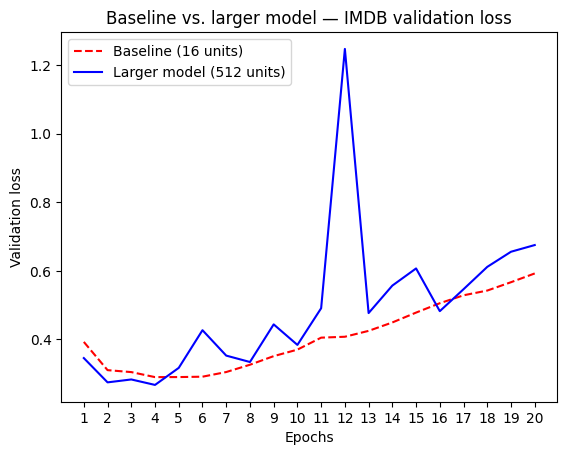

In [8]:
epochs = range(1, 21)
plt.plot(epochs, history_original.history["val_loss"], "r--",
         label="Baseline (16 units)")
plt.plot(epochs, history_larger.history["val_loss"], "b-",
         label="Larger model (512 units)")
plt.title("Baseline vs. larger model — IMDB validation loss")
plt.xlabel("Epochs")
plt.ylabel("Validation loss")
plt.xticks(epochs)
plt.legend()
plt.show()

---
## Demo 3 — Dropout fixes it


In [9]:
model = keras.Sequential([
    layers.Dense(512, activation="relu"),
    layers.Dropout(0.8),
    layers.Dense(512, activation="relu"),
    layers.Dropout(0.8),
    layers.Dense(1, activation="sigmoid"),
])
model.compile(optimizer="rmsprop",
              loss="binary_crossentropy",
              metrics=["accuracy"])
history_dropout = model.fit(
    train_data, train_labels,
    epochs=20, batch_size=512, validation_split=0.4)

Epoch 1/20
30/30 ━━━━━━━━━━━━━━━━━━━━ 4s 110ms/step - accuracy: 0.5943 - loss: 0.6663 - val_accuracy: 0.8473 - val_loss: 0.4011
Epoch 2/20
30/30 ━━━━━━━━━━━━━━━━━━━━ 2s 16ms/step - accuracy: 0.8206 - loss: 0.4105 - val_accuracy: 0.8780 - val_loss: 0.3051
Epoch 3/20
30/30 ━━━━━━━━━━━━━━━━━━━━ 0s 15ms/step - accuracy: 0.8761 - loss: 0.3073 - val_accuracy: 0.8653 - val_loss: 0.3236
Epoch 4/20
30/30 ━━━━━━━━━━━━━━━━━━━━ 1s 17ms/step - accuracy: 0.8953 - loss: 0.2664 - val_accuracy: 0.8851 - val_loss: 0.2839
Epoch 5/20
30/30 ━━━━━━━━━━━━━━━━━━━━ 0s 14ms/step - accuracy: 0.9238 - loss: 0.2068 - val_accuracy: 0.8796 - val_loss: 0.2996
Epoch 6/20
30/30 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - accuracy: 0.9278 - loss: 0.1841 - val_accuracy: 0.8908 - val_loss: 0.2887
Epoch 7/20
30/30 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - accuracy: 0.9448 - loss: 0.1569 - val_accuracy: 0.8911 - val_loss: 0.3042
Epoch 8/20
30/30 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - accuracy: 0.9490 - loss: 0.1432 - val_accuracy: 0.8923 - 

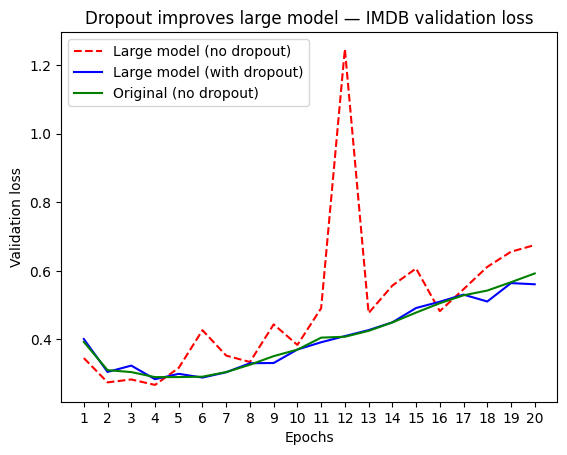

In [10]:
epochs = range(1, 21)
plt.plot(epochs, history_larger.history["val_loss"], "r--",
         label="Large model (no dropout)")
plt.plot(epochs, history_dropout.history["val_loss"], "b-",
         label="Large model (with dropout)")
plt.plot(epochs, history_original.history["val_loss"], "g-",
         label="Original (no dropout)")
plt.title("Dropout improves large model — IMDB validation loss")
plt.xlabel("Epochs")
plt.ylabel("Validation loss")
plt.xticks(epochs)
plt.legend()
plt.show()